# Feature-importance report — end to end, one schema in, one folder out

**Set the parameters, Run All, get a folder.** This is the operational notebook of
the package: it reads a `unified_schema_*`, joins the pools, ranks every feature,
optionally computes the bar and the holdout, and writes a **self-describing report
directory** — tables as CSV, figures as PNG, and a `metadata.json` recording
everything needed to reproduce the run and to know what it may be compared against.

The three study notebooks answer *what did we learn*. This one answers *run it and
give me the artefacts*.

| notebook | for |
|---|---|
| [study_1__vcb_unwindowed.ipynb](study_1__vcb_unwindowed.ipynb) | the un-windowed baseline, `d=1` |
| [study_2__vcb_windowed.ipynb](study_2__vcb_windowed.ipynb) | the sequence-model setup, `d=20` |
| [study_3__null_and_holdout.ipynb](study_3__null_and_holdout.ipynb) | whether either result is real (it is not — CONTEXT §6b-6d) |
| [study_4__cross_sectional.ipynb](study_4__cross_sectional.ipynb) | the cross-section, which is (CONTEXT §9) |
| **this one** | **produce and archive a run** |

## ⚠️ Read before quoting anything this writes

**A ranking without a null is descriptive, not evidence.** `RUN_NULL = False` makes
this notebook finish in a minute and produces a `metadata.json` whose `null` field
is `null` and a `README.md` that says so in bold. That is deliberate: CONTEXT §6b
found a positive out-of-sample IC on **shuffled labels**, so `IC > 0` is not a
result. Set `RUN_NULL = True` before the numbers leave your machine.

**A bar belongs to one configuration.** `zscore` moved its own bar 43 % without
touching the data (§6c). Changing the target, the representation, the lookback or
the universe invalidates the previous null — which is why `compare_reports()` puts
those columns beside the IC, so incomparability is visible before the number is.

## Imports

In [19]:
import os
import sys

# ⚠️ EITHER WORKING DIRECTORY MUST WORK - the repo root or this notebook's own
# folder. `sys.path.insert(0, os.path.abspath(".."))` assumed the second: launched
# from the repo root, ".." is the PARENT of the repo and every import below fails
# with ModuleNotFoundError. Walk UP from the CWD to the folder that actually holds
# src/feature_selection, and put that repo's `src` on the path.
#
# REPO_ROOT is reused by the parameter cell: a relative REPORT_ROOT is anchored to
# the repo by `report.write_report` (CONTEXT section 10), so the run folder lands in
# <repo>/reports/feature_selection/ from either CWD - which is the whole point.
def _find_repo_root() -> str:
    here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isdir(os.path.join(here, "src", "feature_selection")):
            return here
        parent = os.path.dirname(here)
        if parent == here:
            raise RuntimeError(
                f"no repo root above {os.getcwd()!r} - expected a folder holding "
                f"src/feature_selection. Start the kernel inside the master-thesis repo."
            )
        here = parent


REPO_ROOT = _find_repo_root()
if os.path.join(REPO_ROOT, "src") not in sys.path:
    sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
print("repo root:", REPO_ROOT)

import pandas as pd
from IPython.display import Image, Markdown, display

from feature_selection import evaluation, plots, report, windows
from feature_selection.selector import FeatureSelector
from feature_selection.unified_reader import UnifiedSchemaReader

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plots.use_theme()

## Parameters — the whole run is configured here

Everything below this cell is mechanical. ⚠️ Each knob that changes an ANSWER is
recorded into `metadata.json`, so a report is never a bare table of feature names.

In [20]:
TICKER = "VCB"  # the schema is unified_schema_<ticker>
# POOLS = ["pool__basic", "pool__economy_united_kingdom", "pool__targets"]
POOLS = ["pool__basic", "pool__economy_australia", "pool__targets"]
TARGET = "return_5day"
OTHER_TARGETS = ["return_10day", "return_rel_5day", "return_rel_10day"]

LOOKBACK = 20  # d — window length in sessions; 1 = un-windowed
HORIZON = 5  # h — must match the target's own horizon
NORMALIZE = "none"  # "none" | "zscore" | "window_relative"
MAX_FEATURES = None  # None = the per-run MEASURED cut (selection_cut, STL-1).
# A number here re-imposes a flat cap, which is almost never what you want: 12
# was chosen for a 27-channel pool and then applied to a 1,458-channel one.
CORR_THRESHOLD = 0.9
N_SPLITS, MIN_TRAIN = 5, 500
DEVICE = "cuda"  # ⚠️ part of the setup, NOT a speed knob — see gpu.py §1.
# "cuda" = every ranker on the GPU. "auto" keeps narrow pools on the host.
RANDOM_STATE = 18  # the SELECTOR seed; the null draws from NULL_SEED=7

RUN_STABILITY = True  # per-fold SHAP ranking (cheap)
RUN_NULL = False  # ⚠️ the BAR. Slow. See the warning above.
N_NULL = 20
RUN_HOLDOUT = False  # score an untouched tail once, with a control
HOLDOUT_START = "2024-06-01"

TOP_N_FIGURES = 30

# ⚠️ THE REPORT ROOT IS A GROUP, NOT A FOLDER PREFERENCE.
# `final_features` unions EVERY run under one root by (schema, target, setup) —
# a key with no term for which pools. ONE root holds every run since 2026-08-10,
# so a basic run and a country run at seed 18 are the SAME setup and get UNIONED
# into ONE table. Separate a build with `--scope`, never with a second root.
#
# ⚠️ RELATIVE, AND ANCHORED TO THE REPO - NOT TO THE CWD. `write_report` joins a
# relative root onto REPO_ROOT, so this lands in <repo>/reports/feature_selection/
# whether the kernel starts at the repo root or in this folder. It did NOT until
# 2026-08-10: a complete run went to src/feature_selection/reports/feature_selection/,
# where outstanding, final_features and pipeline all correctly saw no run at all.
REPORT_ROOT = "reports/feature_selection"
NOTES = ""  # free text, lands in metadata.json and README.md

# ⚠️ Identity and taxonomy columns are never candidates. On a single-ticker panel
# they are constant and would be dropped anyway; naming them keeps that a decision
# rather than an accident, and keeps this cell correct for a multi-ticker panel.
IDENTITY = [
    "exchange",
    "ticker",
    "sector",
    "sector_code",
    "industry_group",
    "industry_group_code",
    "industry",
    "industry_code",
    "sub_industry",
    "sub_industry_code",
]

## 1. Read and join

`UnifiedSchemaReader` types every column from `information_schema` rather than
guessing — psycopg2 returns `numeric` as `Decimal`, which pandas stores as dtype
`object`, so `close_adjust` would otherwise arrive looking like a string column.

⚠️ **`join_log` records which keys each merge actually used** and goes into the
report. Every pool is keyed `(date, exchange, ticker)` as of 2026-08-04, but the
join intersects per pair rather than assuming, so a pool that predates the change
joins correctly instead of silently wrongly.

In [21]:
# ⚠️ THE CALENDAR GUARD. `reader.join` is an INNER join, so a `pool__economy_<country>`
# that is older than `pool__basic` does NOT fail - it silently truncates the panel to
# its own last date and every number below describes the shorter window. Nothing in the
# archived run can reveal that afterwards. Measured 2026-08-10: pool__basic had moved to
# 2026-08-07 while all 19 economy pools sat at 2026-06-25 - six weeks, invisibly.
#
# The Dagster asset `analysis/feature_selection_economy` asserts this before it starts.
# The notebook has no such wrapper, so the check lives here.
with UnifiedSchemaReader(TICKER) as _r:
    _spans = {
        t: _r.read(t)["date"].agg(["min", "max", "count"]).to_dict()
        for t in POOLS
    }
_ends = {t: s["max"] for t, s in _spans.items()}
for _t, _s in _spans.items():
    print(f"{_t:<28} {_s['count']:>7,} rows  {_s['min']:%Y-%m-%d} .. {_s['max']:%Y-%m-%d}")
assert len(set(_ends.values())) == 1, (
    f"pools end on different dates {_ends} - the INNER join would truncate to the "
    f"earliest. Re-materialise unified/pool__economy on this universe first."
)
print("OK - every pool shares one calendar.")

pool__basic                    4,266 rows  2009-06-30 .. 2026-08-07
pool__economy_australia        4,266 rows  2009-06-30 .. 2026-08-07
pool__targets                  4,266 rows  2009-06-30 .. 2026-08-07
OK - every pool shares one calendar.


In [22]:
reader = UnifiedSchemaReader(TICKER).connect()
overview = reader.overview()
panel = reader.join(POOLS)
join_log = reader.join_log
schema_name, database = reader.schema, reader.database
reader.close()

print(
    f"{schema_name}: {panel.shape[0]:,} rows x {panel.shape[1]} columns "
    f"({panel['date'].min():%Y-%m-%d} -> {panel['date'].max():%Y-%m-%d})"
)
overview

unified_schema_vcb: 4,266 rows x 222 columns (2009-06-30 -> 2026-08-07)


,table,rows,columns,key_columns,first_date,last_date
0,pool__basic,4266,38,"date, exchange, ticker",2009-06-30,2026-08-07
1,pool__economy_australia,4266,183,"date, exchange, ticker",2009-06-30,2026-08-07
2,pool__economy_european_union,4266,129,"date, exchange, ticker",2009-06-30,2026-08-07
3,pool__economy_germany,4266,180,"date, exchange, ticker",2009-06-30,2026-08-07
4,pool__economy_hong_kong_china,4266,95,"date, exchange, ticker",2009-06-30,2026-08-07
5,pool__economy_india,4266,124,"date, exchange, ticker",2009-06-30,2026-08-07
6,pool__economy_indonesia,4266,108,"date, exchange, ticker",2009-06-30,2026-08-07
7,pool__economy_japan,4266,184,"date, exchange, ticker",2009-06-30,2026-08-07
8,pool__economy_mainland_china,4266,167,"date, exchange, ticker",2009-06-30,2026-08-07
9,pool__economy_malaysia,4266,113,"date, exchange, ticker",2009-06-30,2026-08-07


In [23]:
pd.DataFrame(join_log)

,table,join_keys,how,rows_before,rows_after,columns_added,duplicate_columns_dropped
0,pool__economy_australia,"date, exchange, ticker",inner,4266,4266,180,
1,pool__targets,"date, exchange, ticker",inner,4266,4266,4,


### The target's own arithmetic

In [24]:
labels = pd.DataFrame(
    [
        {
            "target": column,
            "labelled": int(panel[column].notna().sum()),
            "unlabelled_tail": int(panel[column].isna().sum()),
            "mean": round(float(panel[column].mean()), 6),
            "sd": round(float(panel[column].std()), 6),
        }
        for column in [TARGET] + [c for c in OTHER_TARGETS if c in panel.columns]
    ]
)
labels

,target,labelled,unlabelled_tail,mean,sd
0,return_5day,4261,5,0.003149,0.043027
1,return_10day,4256,10,0.006275,0.059864
2,return_rel_5day,4253,13,0.001021,0.031979
3,return_rel_10day,4248,18,0.002075,0.043732


## 2. Run the selection

Six rankers → rank-average ensemble → correlation prune at channel level → purged
walk-forward. ⚠️ The purge gap is `d + h - 1`, not `h` (CONTEXT §1a).

In [25]:
selector = FeatureSelector(
    panel=panel,
    target=TARGET,
    exclude=IDENTITY + [c for c in OTHER_TARGETS if c != TARGET],
    max_features=MAX_FEATURES,
    corr_threshold=CORR_THRESHOLD,
    horizon=HORIZON,
    lookback=LOOKBACK,
    window_stats=windows.WINDOW_STATS,
    normalize=NORMALIZE,
    n_splits=N_SPLITS,
    min_train=MIN_TRAIN,
    device=DEVICE,
    random_state=RANDOM_STATE,
    holdout_start=HOLDOUT_START if RUN_HOLDOUT else None,
)

result = selector.run(stability=RUN_STABILITY)
result.setup.to_frame().T

,target,horizon_h,lookback_d,normalize,purge_gap_rows,window_stats,dropped_by_normalize,dev_samples,holdout_start,holdout_rows,purged_at_boundary,channels,design_columns,kept,device
setup,return_5day,5,20,none,24,"last, mean, slope, sd, min, max",4,4242,—,0,0,202,1208,129,cuda


### The ranking — this is the deliverable

In [26]:
result.ranking.round(3)

,ensemble,kept,dropped_for,spearman,mutual_info,xgb_gain,xgb_shap,lasso,permutation
australia__economy__money__economics__aufer,16.500,True,,0.228,0.692,0.550,0.561,0.342,0.204
australia__economy__trade__economics__aubot,34.833,True,,0.212,0.555,0.531,0.528,0.037,1.000
australia__economy__government__economics__aufe,43.500,True,,0.166,0.688,0.231,0.336,0.105,0.125
australia__economy__government__economics__augbv,44.333,True,,0.200,0.608,0.277,0.381,0.049,0.344
australia__economy__housing__economics__auhpimm,44.667,True,,0.277,0.563,0.692,0.514,0.257,0.000
...,...,...,...,...,...,...,...,...,...
australia__economy__trade__economics__auti,139.833,True,,0.042,0.611,0.063,0.007,0.000,0.000
australia__economy__taxes__economics__aussre,140.333,True,,0.137,0.095,0.000,0.000,0.017,0.000
australia__economy__taxes__economics__aussr,142.333,False,close_adjust,0.005,0.378,0.106,0.055,0.000,0.000
australia__economy__gdp__economics__aufygdpg,147.667,True,,0.040,0.561,0.045,0.003,0.000,0.000


In [27]:
print("kept:", result.kept)
print("\ndropped as redundant:")
display(pd.Series(result.dropped_correlated, name="duplicated").to_frame())
if result.dead_methods:
    print(f"\n⚠️ dead methods (separated nothing): {result.dead_methods}")

kept: ['australia__economy__money__economics__aufer', 'australia__economy__trade__economics__aubot', 'australia__economy__government__economics__aufe', 'australia__economy__government__economics__augbv', 'australia__economy__housing__economics__auhpimm', 'australia__economy__trade__economics__auexp', 'australia__economy__labor__economics__auemc', 'australia__economy__housing__economics__aurpp', 'australia__economy__business__economics__auic', 'foreign_own', 'australia__economy__gdp__fred__naexkp01auq657s', 'close_adjust', 'australia__economy__prices__economics__auie', 'australia__economy__money__economics__audir', 'australia__economy__prices__economics__aucpyy', 'australia__economy__business__economics__aubr', 'australia__economy__labor__economics__auyur', 'australia__economy__consumer__economics__aublr', 'australia__economy__business__economics__ausp', 'volume_negotiated', 'australia__economy__consumer__economics__aucci', 'australia__economy__business__economics__aumpryy', 'australia_

,duplicated
australia__economy__housing__economics__auahp,close_adjust
australia__economy__money__economics__auintr,australia__economy__consumer__economics__aublr
australia__economy__business__economics__aucorpi,australia__economy__trade__economics__auexp
australia__economy__housing__economics__auhp,australia__economy__housing__economics__aurpp
australia__economy__money__economics__aucbbs,close_adjust
...,...
australia__economy__labor__economics__auram,close_adjust
australia__economy__labor__economics__auwhs,australia__economy__trade__economics__aubot
australia__economy__business__economics__auiibs,australia__economy__business__economics__auii
australia__economy__taxes__economics__aussr,close_adjust


### Walk-forward — the only numbers carrying a generalisation claim

In [28]:
display(result.validation.round(4))
evaluation.ic_summary(result.validation, HORIZON).to_frame().T.round(4)

,fold,feature_set,n_channels,n_columns,n_train,n_test,n_eff_test,ic,r2,hit_rate
0,fold 1,all channels,202,1208,500,743,148.6,0.0740,-0.2547,0.5114
1,fold 1,selected,129,774,500,743,148.6,0.0746,-0.2711,0.5168
2,fold 2,all channels,202,1208,1243,743,148.6,0.0614,-1.0031,0.4818
3,fold 2,selected,129,774,1243,743,148.6,0.1189,-0.9091,0.4697
4,fold 3,all channels,202,1208,1986,743,148.6,0.0294,-0.3324,0.4603
5,fold 3,selected,129,774,1986,743,148.6,0.1610,-0.6118,0.4199
6,fold 4,all channels,202,1208,2729,743,148.6,0.0602,-0.6318,0.4926
7,fold 4,selected,129,774,2729,743,148.6,0.0887,-0.6200,0.5155
8,fold 5,all channels,202,1208,3472,746,149.2,0.0733,-0.2867,0.4759
9,fold 5,selected,129,774,3472,746,149.2,0.0796,-0.1350,0.4920


,folds,ic_mean,ic_trend_per_fold,ic_min,ic_max,ic_fold_sd,hit_rate,n_test_rows,n_eff_per_fold,se_ic_per_fold
selected,5.0,0.1046,-0.002,0.0746,0.161,0.0359,0.4828,743.0,148.6,0.0823


## 3. The bar, and the holdout

⚠️ Both are optional and both are OFF by default, because both are slow — and both
are what turn a ranking into evidence. A report written without them says so.

In [29]:
null = None
if RUN_NULL:

    def factory(frame):
        clone = FeatureSelector(
            panel=frame,
            target=TARGET,
            exclude=IDENTITY + [c for c in OTHER_TARGETS if c != TARGET],
            max_features=MAX_FEATURES,
            corr_threshold=CORR_THRESHOLD,
            horizon=HORIZON,
            lookback=LOOKBACK,
            normalize=NORMALIZE,
            n_splits=N_SPLITS,
            min_train=MIN_TRAIN,
            device=DEVICE,
            random_state=RANDOM_STATE,
        )
        return clone.run(stability=False)

    observed = evaluation.ic_summary(result.validation, HORIZON)["ic_mean"]
    null = evaluation.null_distribution(
        panel=panel,
        target=TARGET,
        factory=factory,
        observed=observed,
        horizon=HORIZON,
        lookback=LOOKBACK,
        n_draws=N_NULL,
        seed=7,
        label=f"{schema_name} / {TARGET}",
    )
    display(null.summary().to_frame().T)
else:
    print("⚠️ RUN_NULL is False — this report will record that no bar was computed.")

⚠️ RUN_NULL is False — this report will record that no bar was computed.


In [30]:
holdout = selector.score_holdout(result) if RUN_HOLDOUT else None
if holdout is not None:
    display(holdout.round(4))

## 4. Write the report

One folder: `metadata.json`, `README.md`, the CSVs and `figures/*.png`.

In [31]:
written = report.write_report(
    result,
    selector=selector,
    panel=panel,
    schema=schema_name,
    tables=POOLS,
    database=database,
    join_log=join_log,
    null=null,
    holdout=holdout,
    notes=NOTES,
    top=TOP_N_FIGURES,
    root=REPORT_ROOT,
)
written.summary().to_frame().T

,run_id,schema,tables,target,rows,channels,kept,ic_mean,ic_trend,hit_rate,null_bar,clears_null,files,path
report,2026-08-10_235436__vcb__basic+economy_australi...,unified_schema_vcb,"pool__basic, pool__economy_australia, pool__ta...",return_5day,4266,202,129,0.104573,-0.002026,0.482779,None,None,18,reports/feature_selection\2026-08-10_235436__v...


In [32]:
print(written.path)
for artefact in written.metadata["artifacts"]:
    print(f"  {artefact['bytes']:>9,}  {artefact['file']}")

reports/feature_selection\2026-08-10_235436__vcb__basic+economy_australia__return_5day
     46,505  feature_importance.csv
    154,199  design_scores.csv
      1,098  validation.csv
     12,874  target_correlation.csv
    819,009  channel_correlation.csv
     14,158  stability.csv
     10,708  coverage.csv
    254,869  figures/01_ensemble_ranking.png
    383,018  figures/02_method_heatmap.png
    233,052  figures/03_target_correlation.png
    456,231  figures/04_channel_correlation.png
    250,439  figures/05_stat_profile.png
     47,293  figures/06_validation.png
    298,077  figures/07_stability.png
    454,125  figures/08_coverage.png
     40,628  figures/09_target_distribution.png


### The README the run wrote about itself

In [33]:
display(
    Markdown(open(os.path.join(written.path, "README.md"), encoding="utf-8").read())
)

# Feature-importance run — `return_5day`

*Generated 2026-08-10T16:54:44.661904+00:00 at commit `2df3d23f+dirty`.*

## Input

- **schema** `unified_schema_vcb` (database `database_main_v2`)
- **tables** `pool__basic`, `pool__economy_australia`, `pool__targets`
- **panel** 4,266 rows x 222 columns
- **range** 2009-06-30 to 2026-08-07 (4266 sessions, 1 tickers)

## Target

- **`return_5day`** — forward 5-session return on close_adjust
- horizon **5** sessions; 4,261 labelled, 5 unlabelled
- mean +0.00315, sd 0.04303, range -0.1876 to +0.2914

## Setup

| knob | value |
|---|---|
| `selector_class` | FeatureSelector |
| `lookback_d` | 20 |
| `horizon_h` | 5 |
| `normalize` | none |
| `purge_gap_rows` | 24 |
| `window_stats` | last, mean, slope, sd, min, max |
| `n_splits` | 5 |
| `min_train` | 500 |
| `corr_threshold` | 0.9 |
| `device` | cuda |
| `random_state` | 18 |
| `permutation_repeats` | 10 |
| `holdout_start` | — |
| `dev_samples` | 4242 |
| `design_columns` | 1208 |

## Result

- **129 of 202 channels kept** after the |rho| >= 0.9 redundancy prune
- **top 10 by ensemble rank**: `australia__economy__money__economics__aufer`, `australia__economy__trade__economics__aubot`, `australia__economy__government__economics__aufe`, `australia__economy__government__economics__augbv`, `australia__economy__housing__economics__auhpimm`, `australia__economy__trade__economics__auexp`, `australia__economy__labor__economics__auemc`, `australia__economy__housing__economics__aurpp`, `australia__economy__business__economics__auic`, `foreign_own`

| metric | selected | all channels |
|---|---|---|
| `ic_mean` | +0.1046 | +0.0597 |
| `ic_trend_per_fold` | -0.0020 | -0.0002 |
| `hit_rate` | +0.4828 | +0.4844 |
| `n_eff_per_fold` | 148.6 | 148.6 |

## The bar

- ⚠️ **NO NULL WAS COMPUTED FOR THIS RUN.** A positive IC is not a result on its own — see `CONTEXT.md` §6b and §8. Treat the ranking below as descriptive until a shuffled-label null has been run for *this* configuration.

## Files

- `feature_importance.csv`
- `design_scores.csv`
- `validation.csv`
- `target_correlation.csv`
- `channel_correlation.csv`
- `stability.csv`
- `coverage.csv`
- `figures/01_ensemble_ranking.png`
- `figures/02_method_heatmap.png`
- `figures/03_target_correlation.png`
- `figures/04_channel_correlation.png`
- `figures/05_stat_profile.png`
- `figures/06_validation.png`
- `figures/07_stability.png`
- `figures/08_coverage.png`
- `figures/09_target_distribution.png`
- `metadata.json`


### The figures

01_ensemble_ranking.png


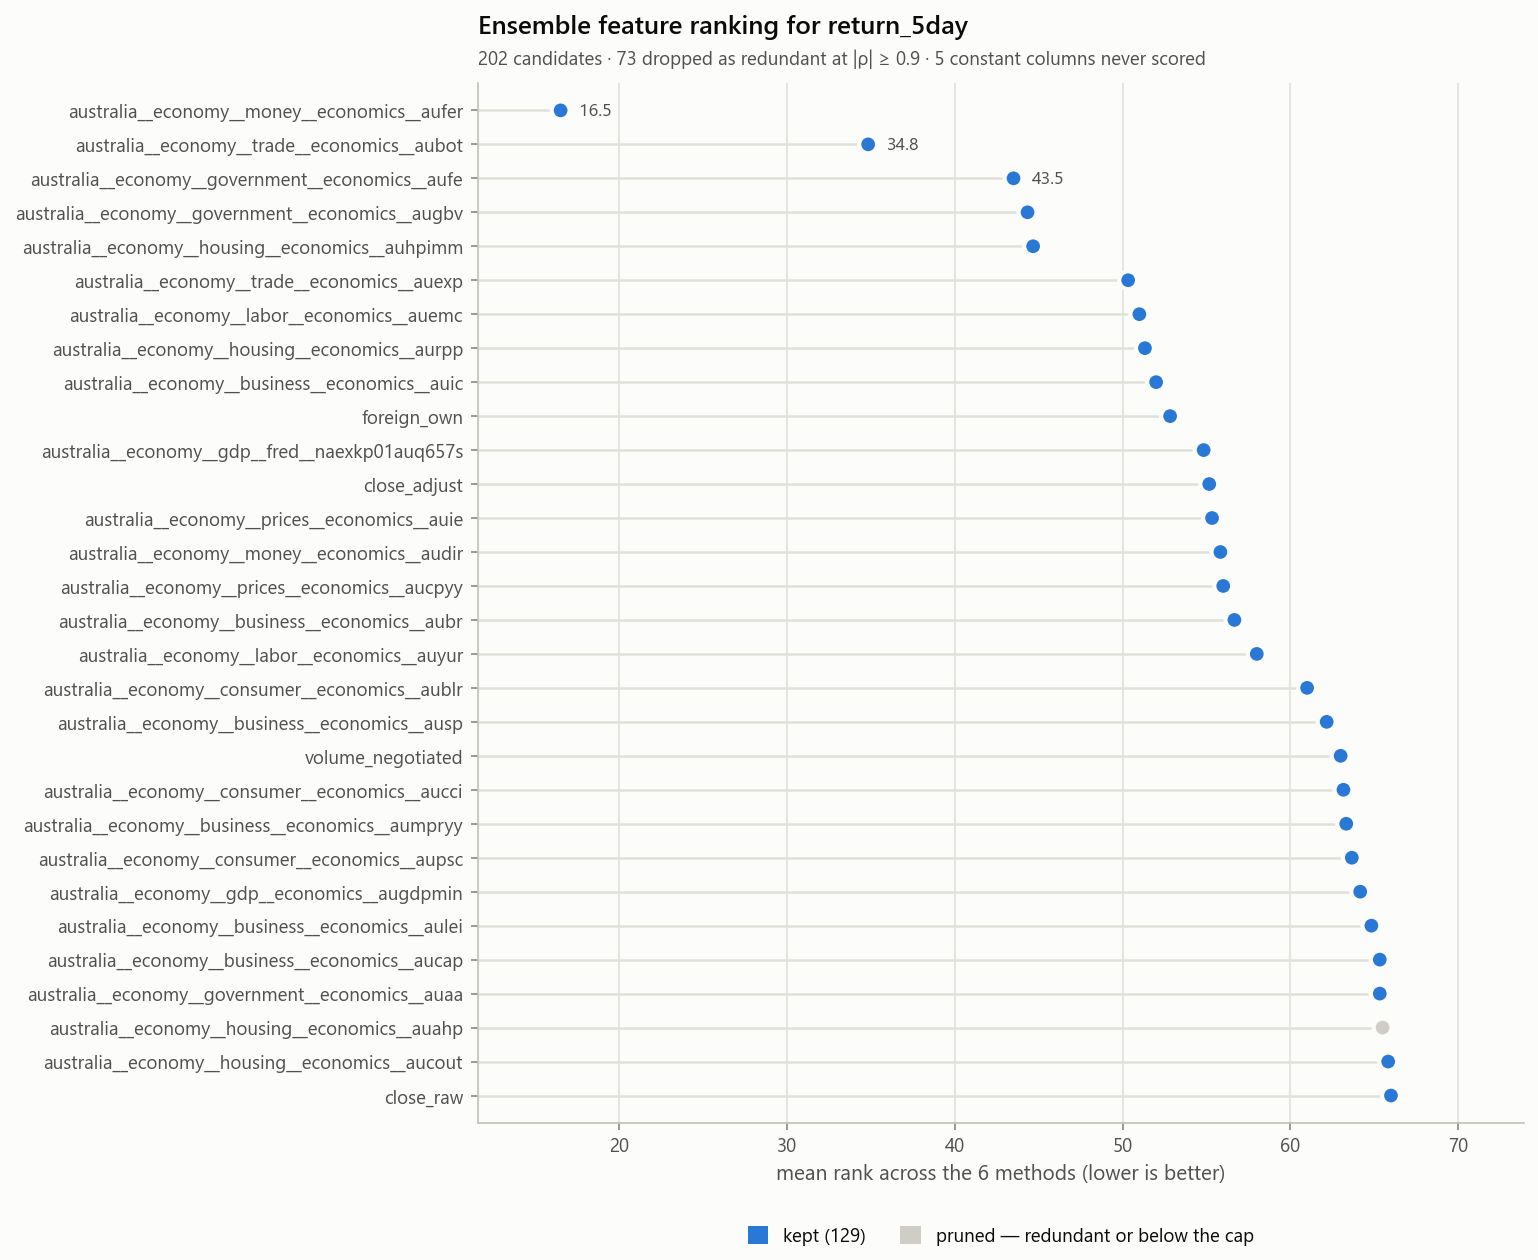

02_method_heatmap.png


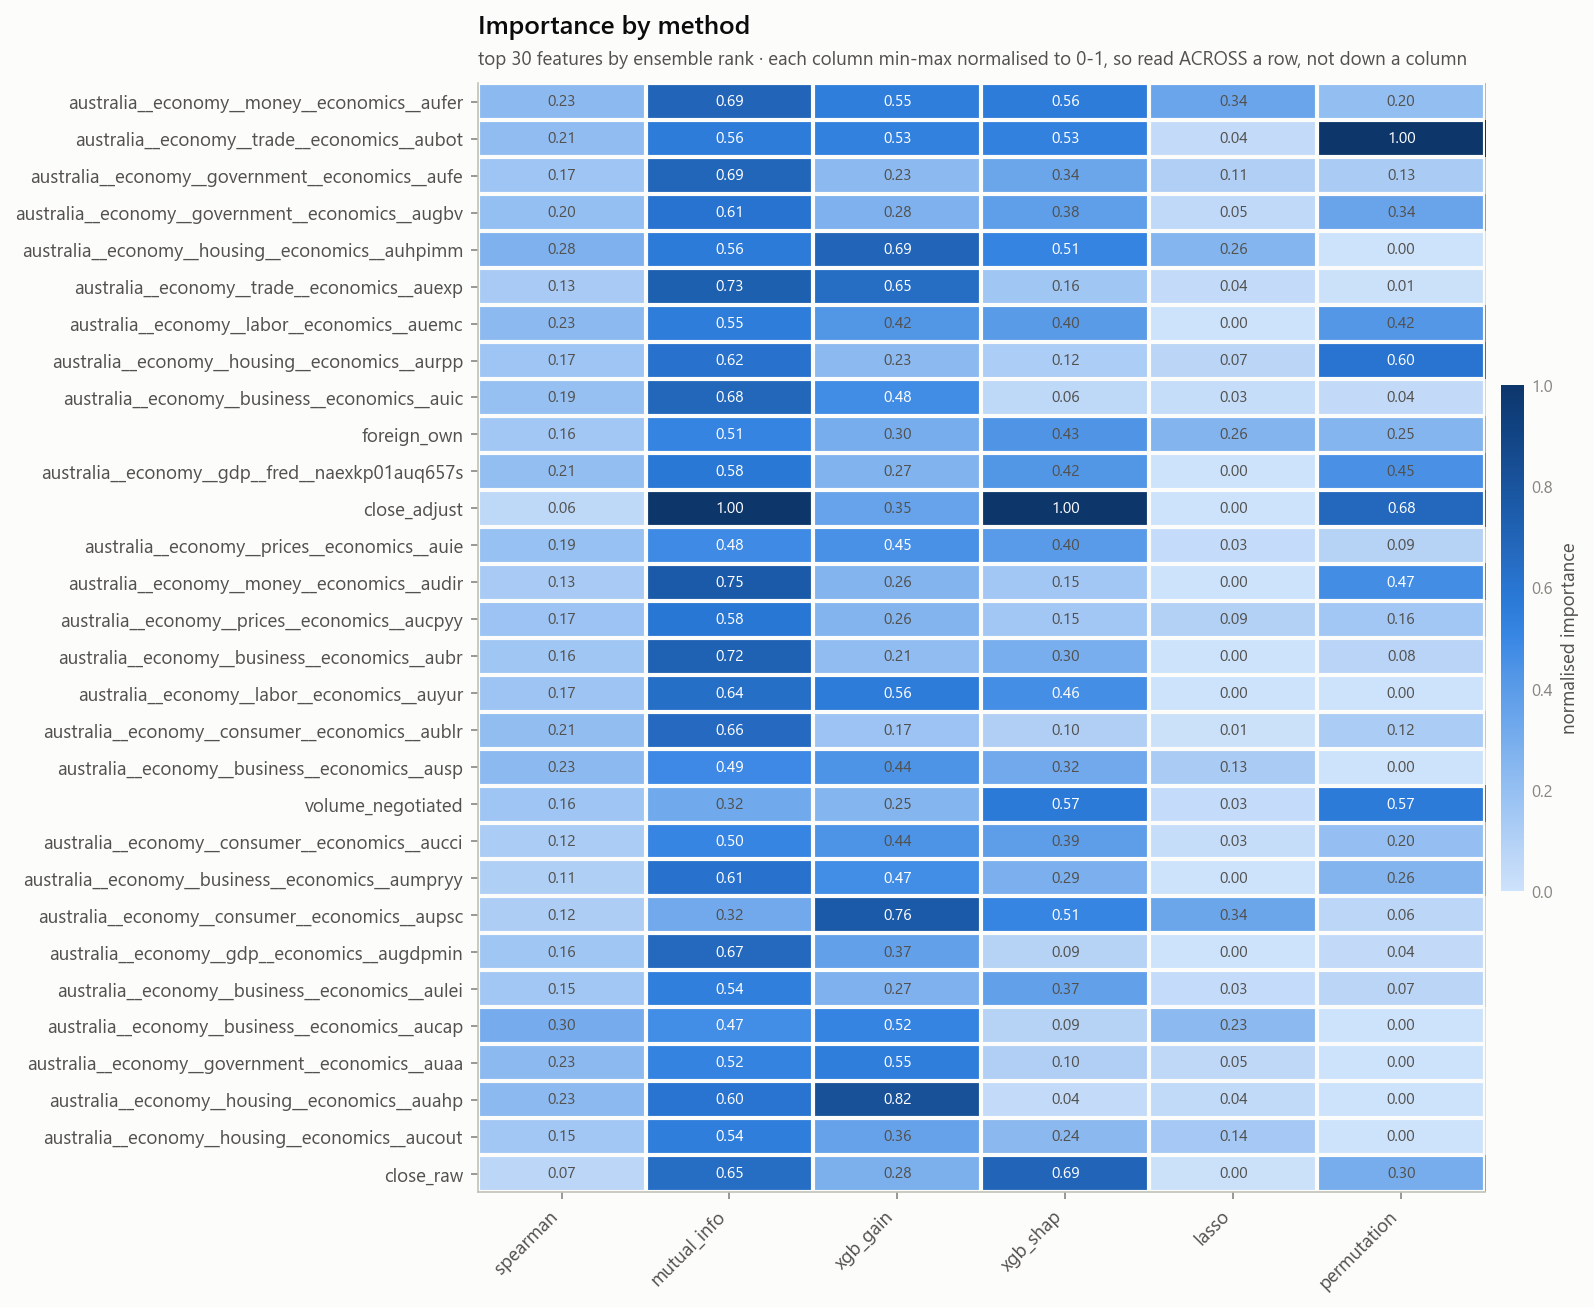

03_target_correlation.png


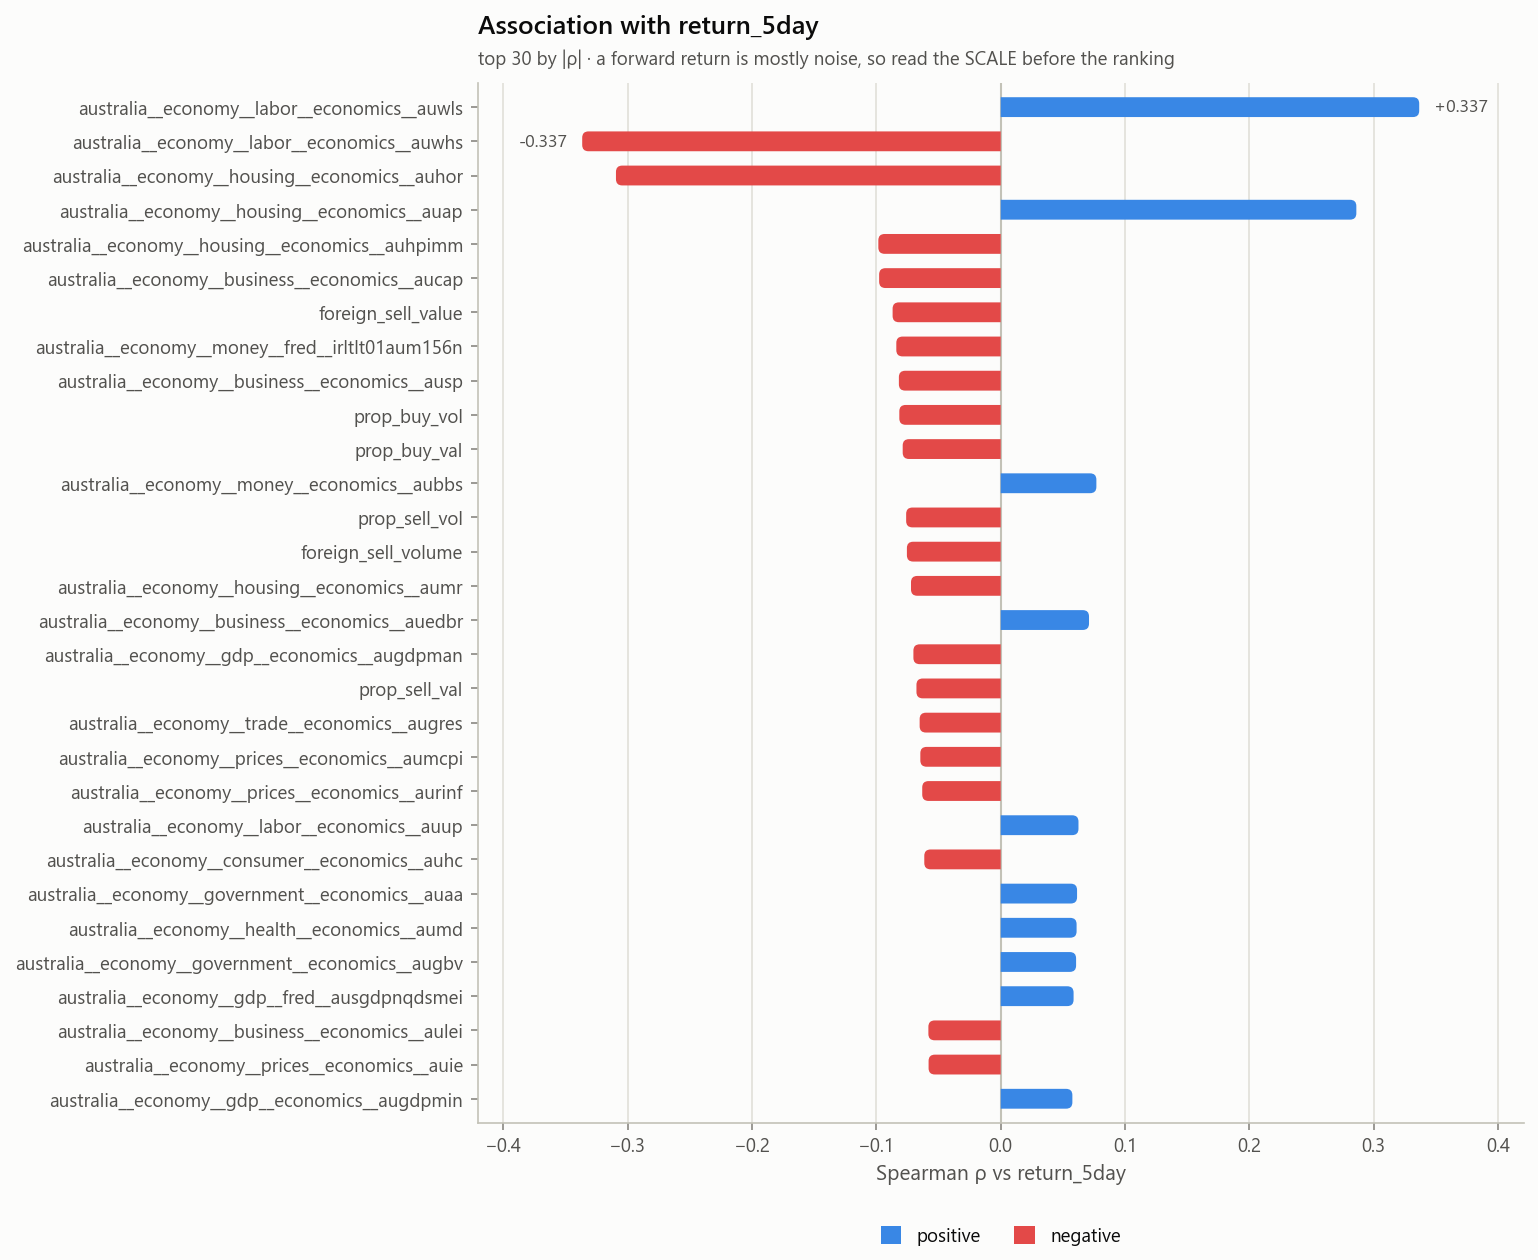

04_channel_correlation.png


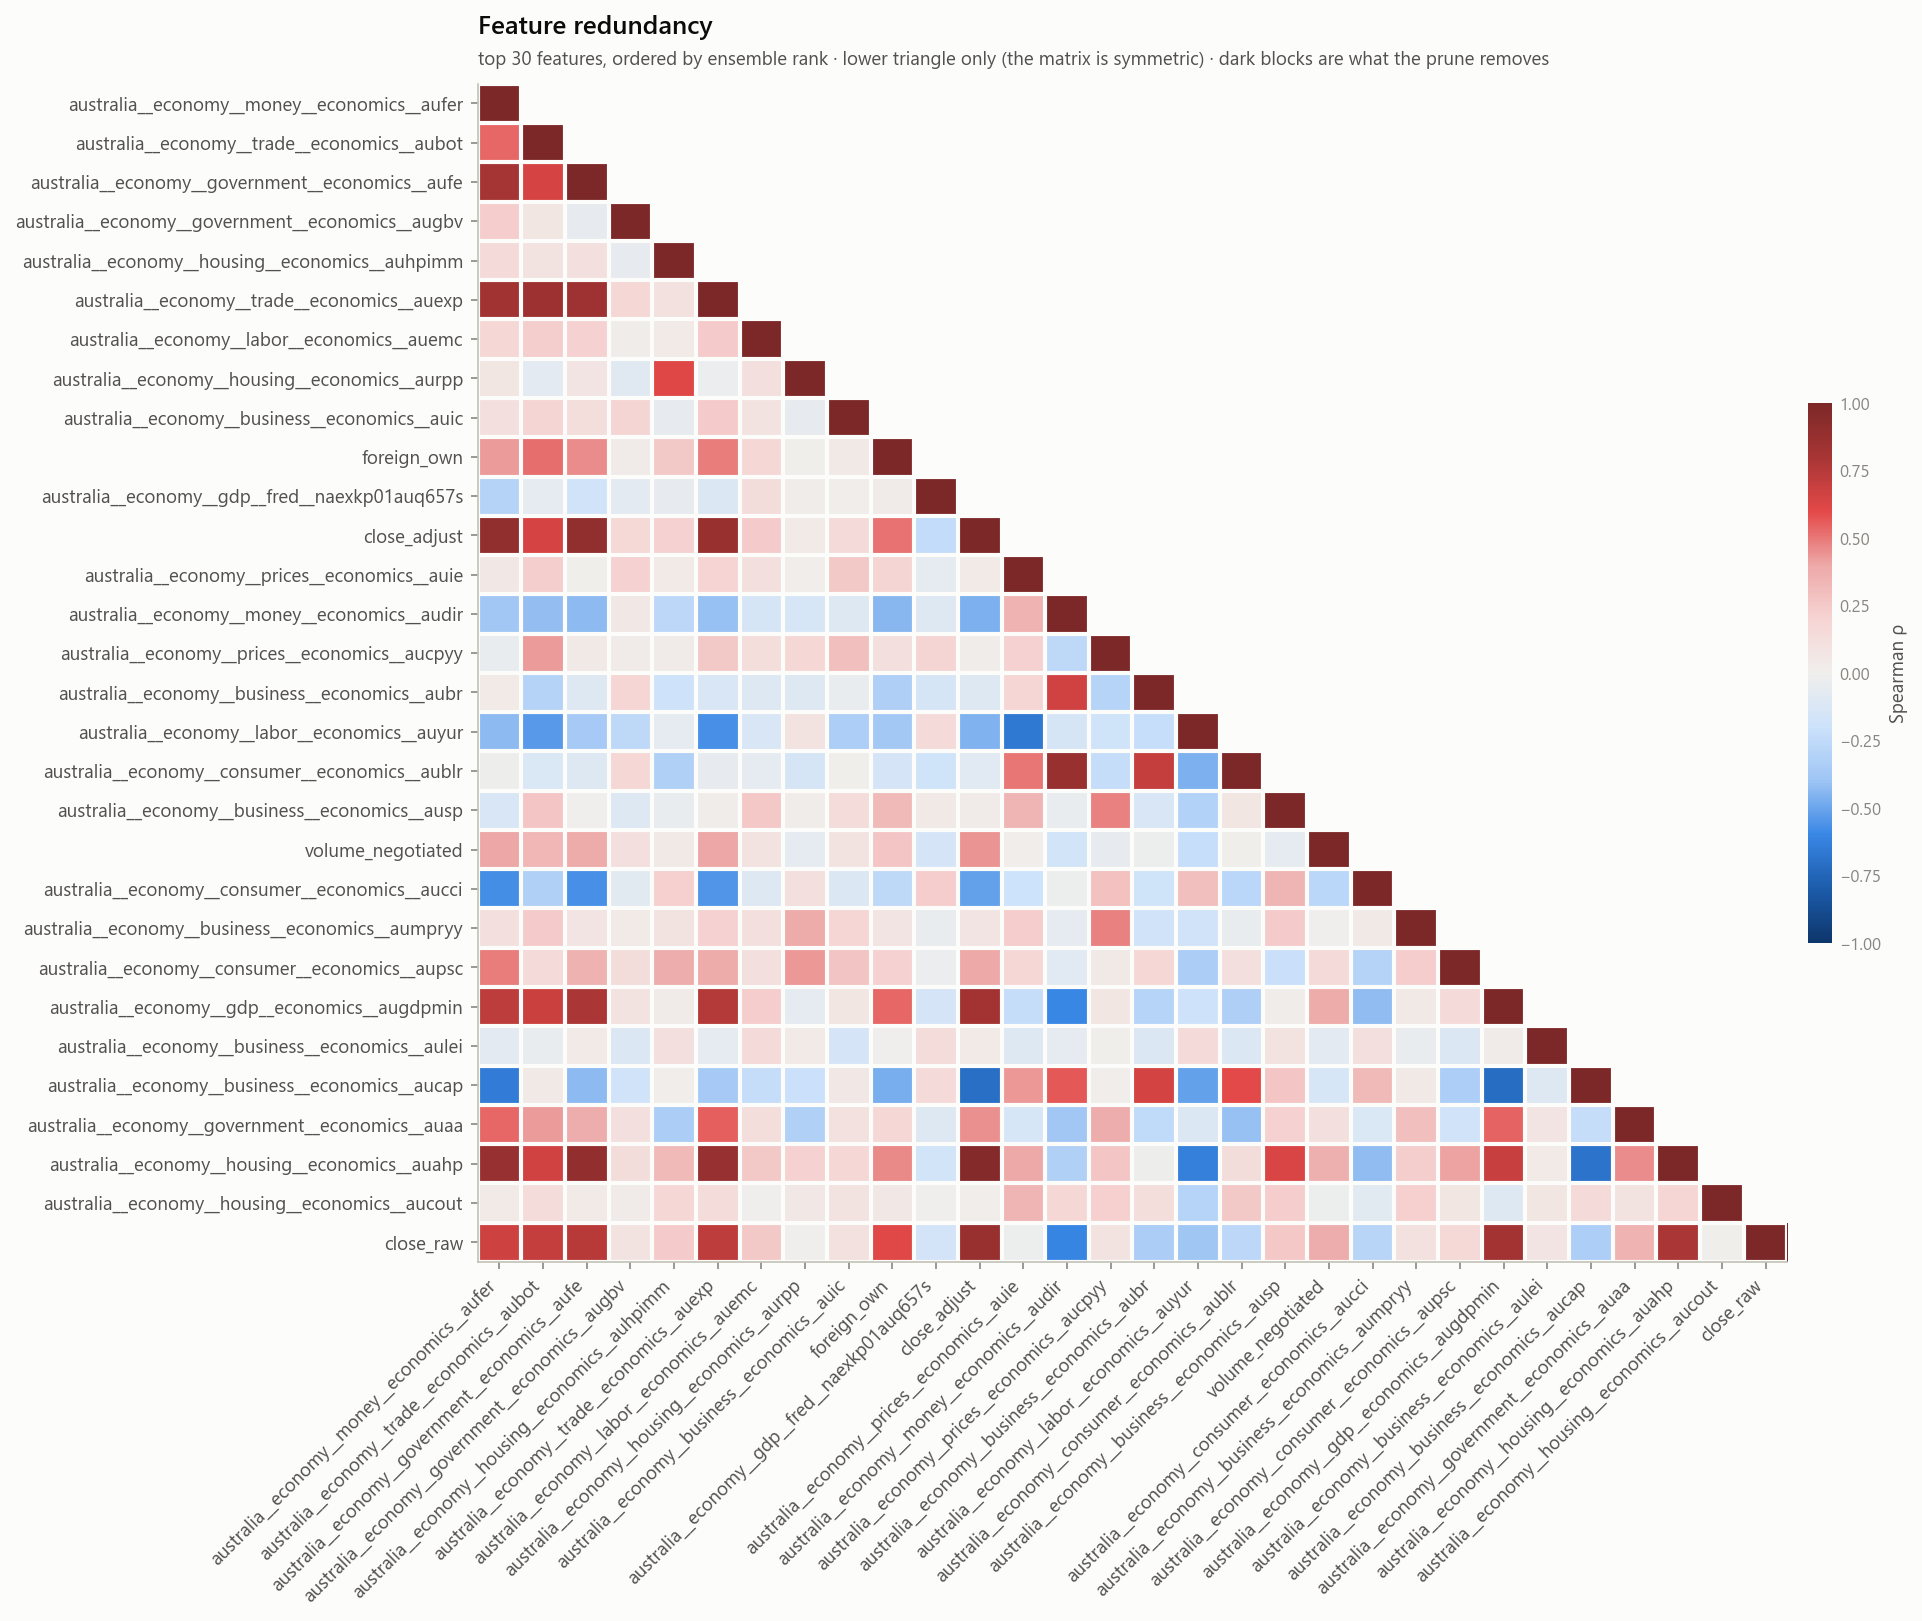

05_stat_profile.png


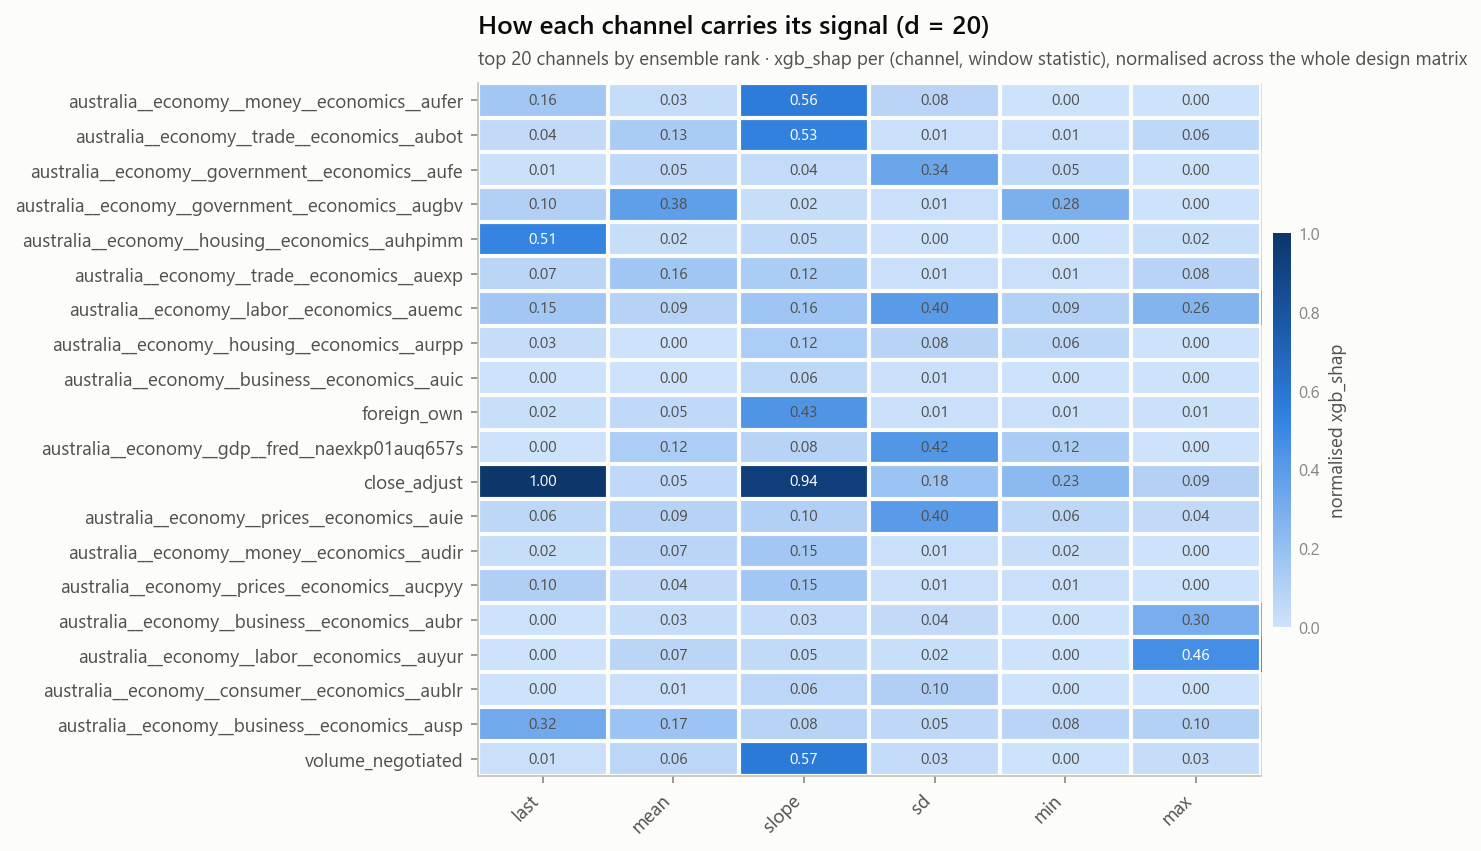

06_validation.png


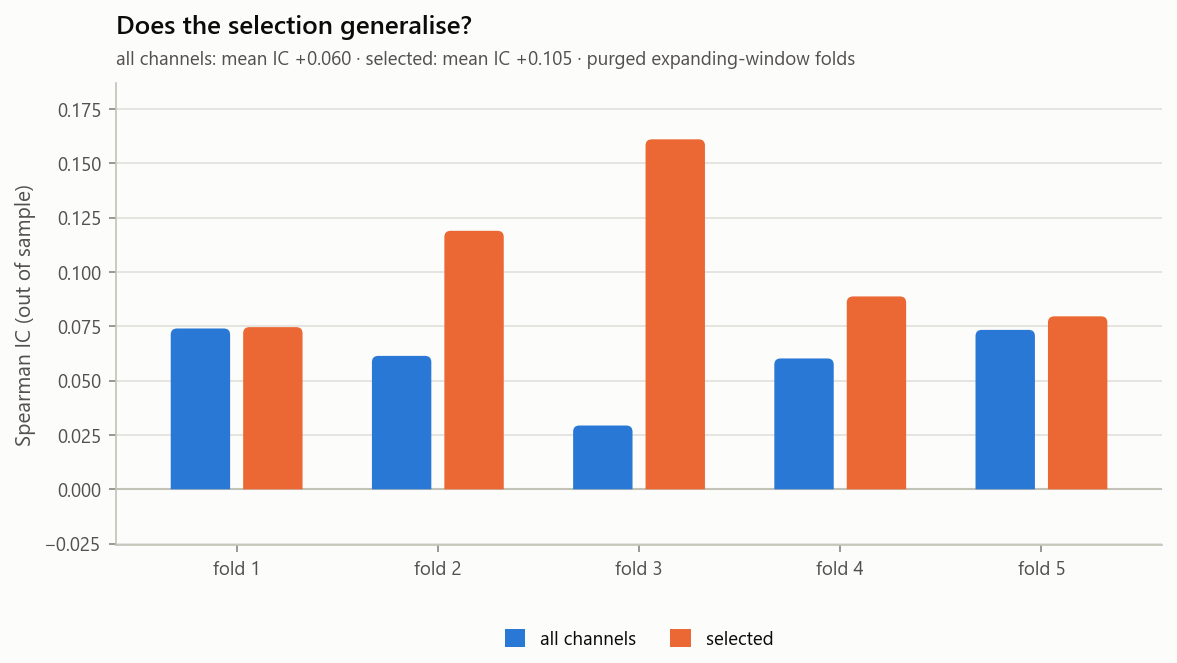

07_stability.png


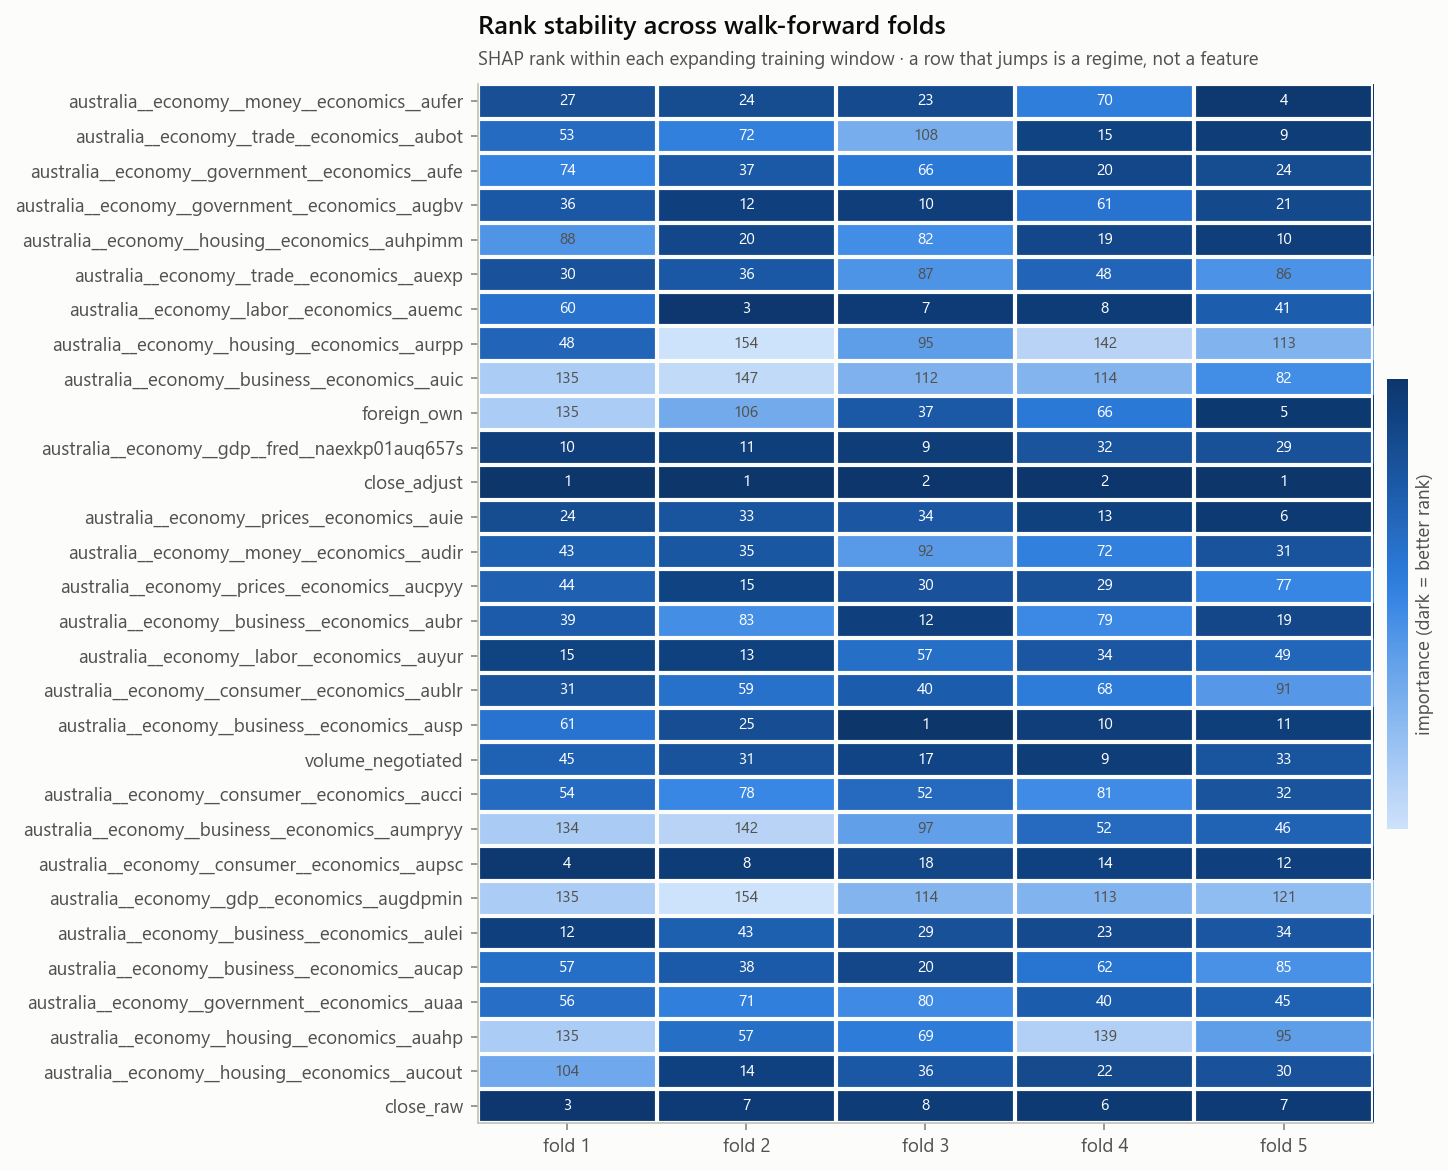

08_coverage.png


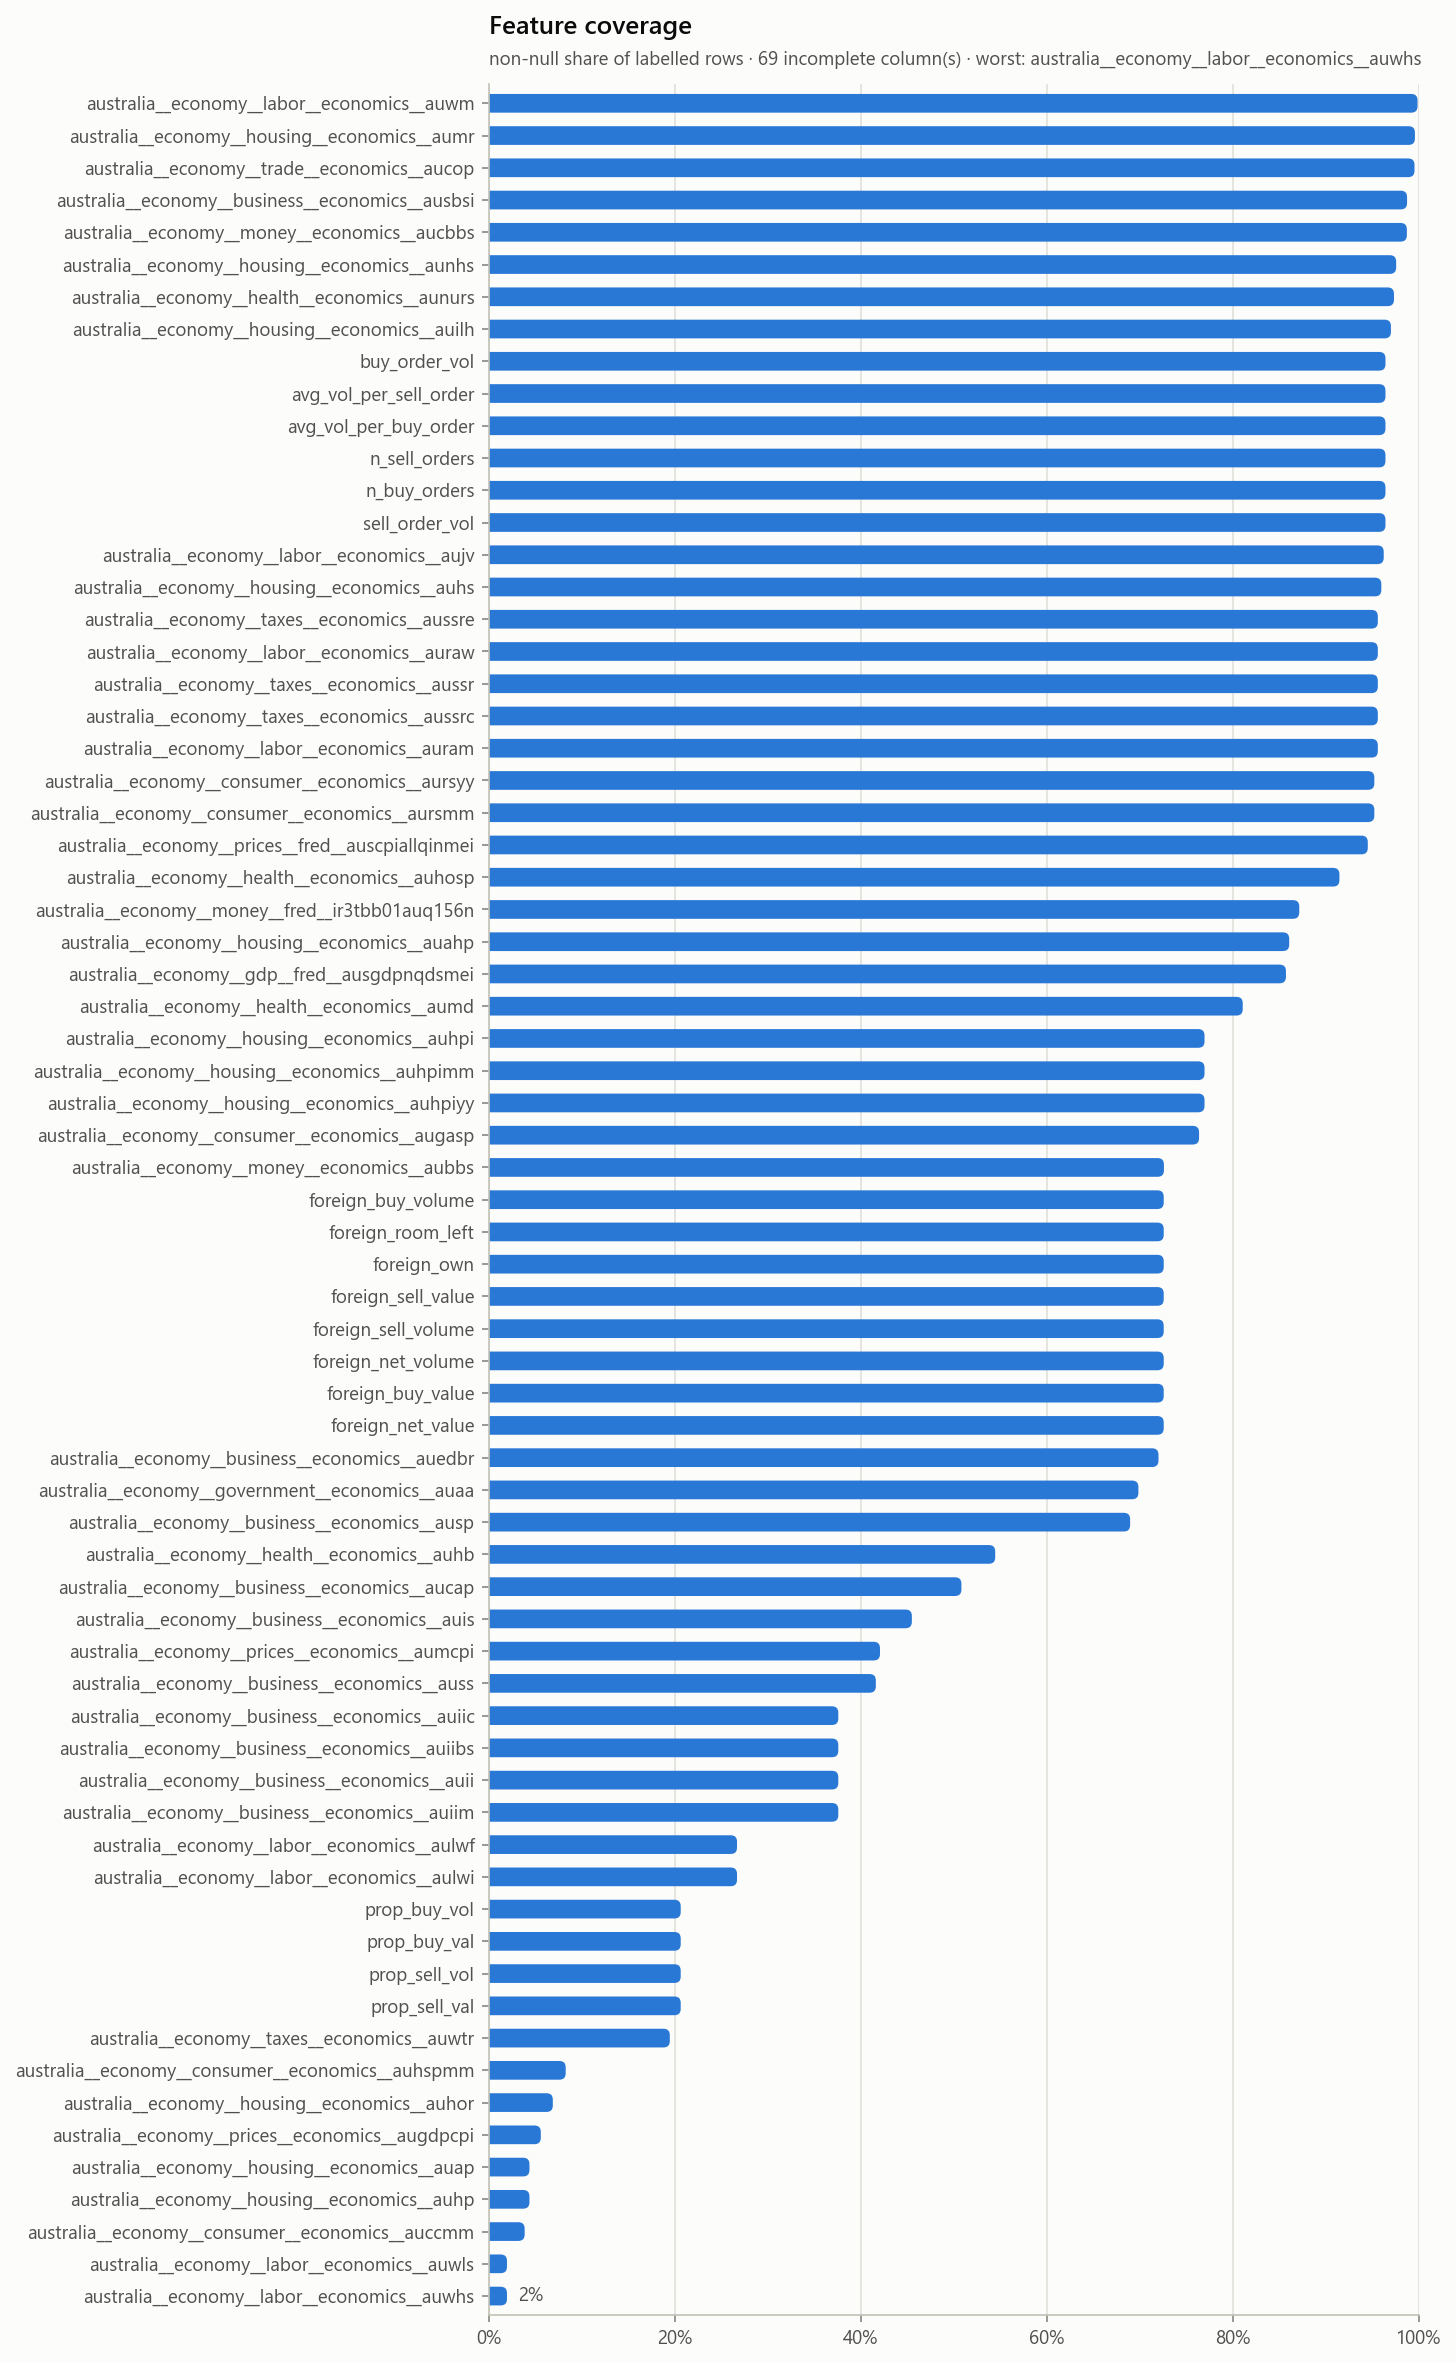

09_target_distribution.png


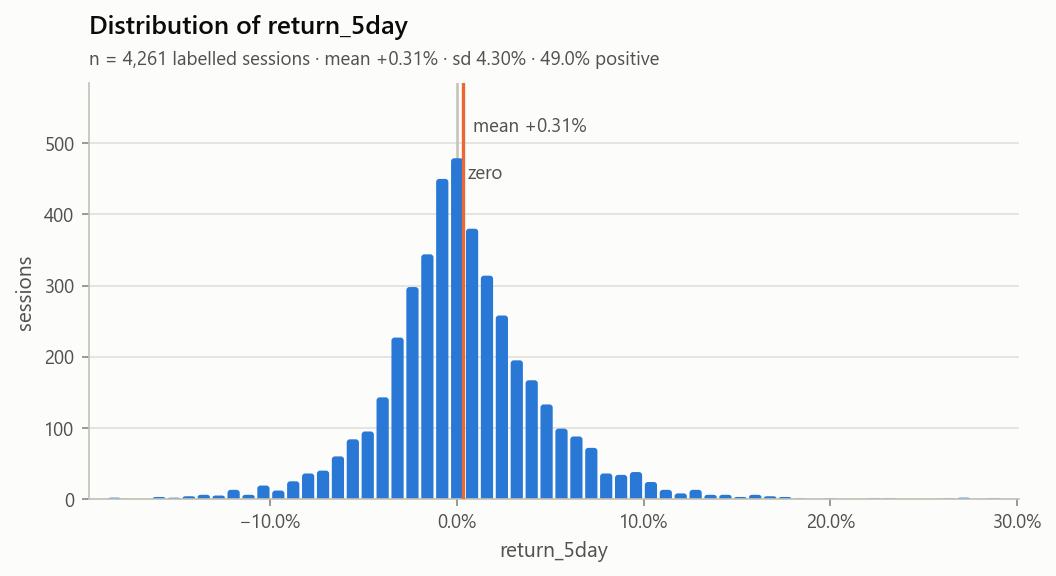

In [34]:
for figure in written.figures:
    print(os.path.basename(figure))
    display(Image(filename=figure, width=760))

### The feature-importance CSV, read back

In [35]:
pd.read_csv(written.importance_csv, index_col="channel").round(3)

,rank,ensemble,kept,dropped_for,spearman,mutual_info,xgb_gain,xgb_shap,lasso,permutation,spearman_vs_target,best_stat__spearman,best_stat__mutual_info,best_stat__xgb_gain,best_stat__xgb_shap,best_stat__lasso,best_stat__permutation
channel,,,,,,,,,,,,,,,,,
australia__economy__money__economics__aufer,1,16.500,True,NaN,0.228,0.692,0.550,0.561,0.342,0.204,0.039,slope,max,last,slope,slope,slope
australia__economy__trade__economics__aubot,2,34.833,True,NaN,0.212,0.555,0.531,0.528,0.037,1.000,0.023,slope,min,slope,slope,slope,slope
australia__economy__government__economics__aufe,3,43.500,True,NaN,0.166,0.688,0.231,0.336,0.105,0.125,0.014,sd,last,sd,sd,sd,slope
australia__economy__government__economics__augbv,4,44.333,True,NaN,0.200,0.608,0.277,0.381,0.049,0.344,0.061,min,max,last,mean,min,mean
australia__economy__housing__economics__auhpimm,5,44.667,True,NaN,0.277,0.563,0.692,0.514,0.257,0.000,-0.098,last,max,last,last,last,last
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
australia__economy__trade__economics__auti,198,139.833,True,NaN,0.042,0.611,0.063,0.007,0.000,0.000,0.021,last,last,slope,slope,last,last
australia__economy__taxes__economics__aussre,199,140.333,True,NaN,0.137,0.095,0.000,0.000,0.017,0.000,0.031,slope,mean,last,last,slope,last
australia__economy__taxes__economics__aussr,200,142.333,False,close_adjust,0.005,0.378,0.106,0.055,0.000,0.000,0.008,mean,last,mean,mean,last,last


## 5. Comparing runs

⚠️ **Built to make INCOMPARABILITY visible.** Two runs differing in `target`,
`normalize`, `lookback_d` or the universe are different experiments; their ICs must
not be set beside one another as if the difference were noise. `compare_reports`
puts those columns next to the IC so the difference is seen first.

In [36]:
root = report.DEFAULT_REPORT_ROOT
runs = [
    os.path.join(root, d)
    for d in sorted(os.listdir(root))
    if os.path.exists(os.path.join(root, d, "metadata.json"))
]
report.compare_reports(runs)

,run_id,schema,target,rows,tickers,lookback_d,horizon_h,normalize,feature_normalize,device,kept,ic_mean,hit_rate,null_bar,z_vs_null,clears_null,commit
0,2026-08-10_232333__vcb__basic__return_5day,unified_schema_vcb,return_5day,4266,1,20,5,none,None,cuda,14,0.064474,0.471495,None,None,None,dfef91f7+dirty
